# Classification Images - FashionMNIST

In [1]:
import warnings
warnings.filterwarnings('ignore')

from Training import Training
from Visualization import *
from Noise.GaborNoise.Gabor import Gabor
from Noise.Denoise.Denoise import Denoise
from CNN import FashionMNIST_Model

import torch
import torch.utils.data.dataloader as dataloader
from torchvision import transforms
from torchvision.datasets import FashionMNIST
import numpy as np
import cv2
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import sys
import math
from SpikeTriggeredAveraging import SpikeTriggeredAveraging

from skimage.filters import gaussian
from skimage import exposure
from skimage.restoration import denoise_nl_means, estimate_sigma, denoise_tv_chambolle,denoise_bilateral,denoise_wavelet
import bm3d
from sklearn.decomposition import PCA

### FashionMNIST Dataset

In [3]:
# Downloading Datasets
train = FashionMNIST('./data', train=True, download=True, transform=transforms.Compose([
    transforms.ToTensor(),]),);

test = FashionMNIST('./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),]),);

num_classes = len(train.classes)
img_shape = train.data[0].shape

In [4]:
# Creating Dataloaders
cuda = torch.cuda.is_available()

dataloader_args = dict(shuffle=True, batch_size=256,num_workers=4, pin_memory=True) if cuda else dict(shuffle=True, batch_size=64)
train_loader = dataloader.DataLoader(train, **dataloader_args)
test_loader = dataloader.DataLoader(test, **dataloader_args)

fmnist_loader = {'train':train_loader,'test':test_loader}

### Visualizing our dataset

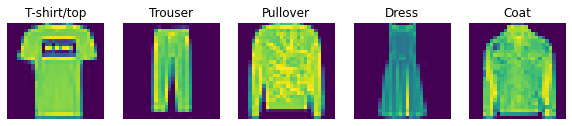

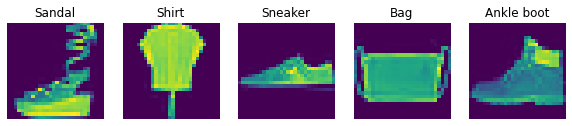

In [5]:
list_of_titles = train.classes
display_data(data = train.data,targets = train.targets.numpy(),class_names=list_of_titles,number_of_columns=5)

### Generating Gabor Noise

$g(x,y;\lambda,\theta,\psi,\sigma,\gamma) = exp(\frac{x'^2+\gamma^2 y'^2}{2\sigma^2}) + exp(i(2\pi\frac{x'}{\lambda}+\psi))$  
$x' = x \cos(\theta) + y\sin(\theta)$   
$y' = -x \sin(\theta) + y\cos(\theta)$  
$\lambda = \text{Wavelength of the sinusoidal factor}$  
$\theta = \text{Orientation of the normal to the parallel stripes}$  
$\psi = \text{Phase offset}$  
$\sigma = \text{Standard deviation of the gaussian envelope}$  
$\gamma = \text{Spatial aspect ratio}$  

In [6]:
gabor = Gabor(pixel = img_shape[0])
n_theta = 4
n_psi = 2
Theta = [i * np.pi /n_theta for i in range(n_theta)]
Psi = [i * np.pi /n_psi for i in range(n_psi)]
ksize = [3, 7, 15]

In [7]:
gabor.generate_gabor_kernels(ksize,sigma_factor=7.0,
                             n_theta=Theta,lambd_factor=2.0,
                             gamma=0.5,n_psi=Psi,
                             ktype=cv2.CV_32F)

960 Gabor kernels have been generated


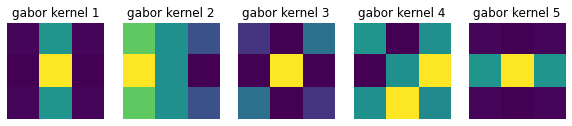

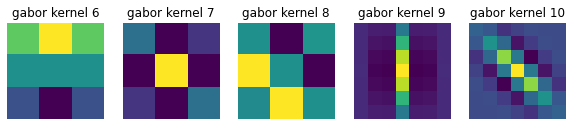

In [8]:
gabor_kernels = gabor.kernels['gabor']
gabor_img_display = [gabor_kernels[i]for i in range(0,960,100)]
gabor_img_title = ['gabor kernel '+str(i) for i in range(1,11)]
grid_display(gabor_img_display,gabor_img_title,5)

100%|██████████| 3/3 [00:00<00:00, 490.18it/s]
960 image kernels generated


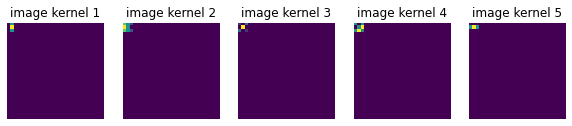

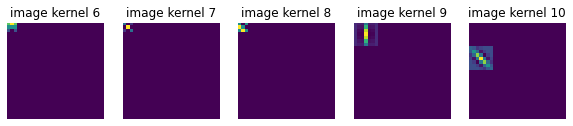

In [9]:
gabor.generate_image_kernels()
image_kernels = gabor.kernels['image']
image_kernel_display = [image_kernels[i]for i in range(0,960,100)]
img_title = ['image kernel '+str(i) for i in range(1,11)]
grid_display(image_kernel_display,img_title,5)

In an attempt to generate the gabor noise, we use Ridge Regression with a regularization factor of $\alpha=0.1$  to find the weights.
The weights undergo Dimensionality Reduction with Principal Component Analysis. We keep the first 250 features and this amounts to 90% of the explained variance.
The principal components and weights are later used to generate the noise samples.

In [11]:
'''n_noise = 1000000
reg_alpha = 0.1
pca_dim = 250
save_as = 'gabor_noise_mnist'
gabor.generate_noise(train_data=train.train_data,reg_alpha=reg_alpha,
                     pca_dim=pca_dim,n_noise=n_noise,save_as=save_as,save_bool=False)
reg_weights = gabor.reg_weights

np.save('cache/fmnist_regweights.npy',reg_weights)'''

"n_noise = 1000000\nreg_alpha = 0.1\npca_dim = 250\nsave_as = 'gabor_noise_mnist'\ngabor.generate_noise(train_data=train.train_data,reg_alpha=reg_alpha,\n                     pca_dim=pca_dim,n_noise=n_noise,save_as=save_as,save_bool=False)\nreg_weights = gabor.reg_weights\n\nnp.save('cache/fmnist_regweights.npy',reg_weights)"

In [10]:
fmnist_noise = np.load('cache/gabor_noise_mnist.npy')
reg_weights = np.load('cache/fmnist_regweights.npy')

The generated image kernels and regression weights are used to reconstruct images

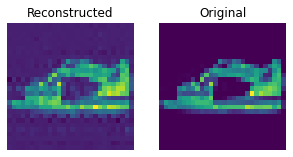

In [11]:
img_kernels = gabor.kernels['image']
orig_v_reconstructed(img_kernels,reg_weights,train,13)

Here are 10 samples of the generated noise samples

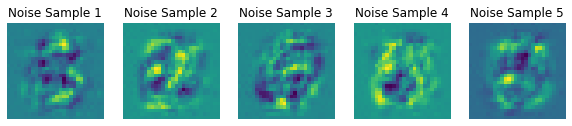

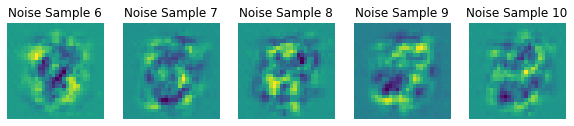

In [12]:
noise_maps(fmnist_noise,10)

### Pass noise through model

We pass the FashionMNIST DataLoader in our Neural Network. The neural network has 3 convolutional blocks and 2 fully connected layers.

In [14]:
model_FashionMNIST = FashionMNIST_Model()
model_FashionMNIST.to(model_FashionMNIST.device)
loss_func = nn.CrossEntropyLoss().to(model_FashionMNIST.device)   
optimizer = optim.Adam(model_FashionMNIST.parameters(), lr=1e-3)

In [21]:
model_FashionMNIST.train_model(fmnist_loader,epochs=70,loss_function=loss_func,optimizer=optimizer)

Epoch: 1 Train Loss: 1.89428 Train Accuracy: 0.63867                    Test Loss: 1.82758 Test Accuracy: 0.63620

Epoch: 2 Train Loss: 1.78085 Train Accuracy: 0.72013                    Test Loss: 1.74517 Test Accuracy: 0.71420

Epoch: 3 Train Loss: 1.68891 Train Accuracy: 0.75217                    Test Loss: 1.71929 Test Accuracy: 0.74650

Epoch: 4 Train Loss: 1.75538 Train Accuracy: 0.77212                    Test Loss: 1.69998 Test Accuracy: 0.75940

Epoch: 5 Train Loss: 1.62943 Train Accuracy: 0.79597                    Test Loss: 1.67508 Test Accuracy: 0.78840

Epoch: 6 Train Loss: 1.65322 Train Accuracy: 0.80565                    Test Loss: 1.66536 Test Accuracy: 0.79680

Epoch: 7 Train Loss: 1.64464 Train Accuracy: 0.81140                    Test Loss: 1.66421 Test Accuracy: 0.79800

Epoch: 8 Train Loss: 1.59730 Train Accuracy: 0.82240                    Test Loss: 1.64887 Test Accuracy: 0.81670

Epoch: 9 Train Loss: 1.66284 Train Accuracy: 0.82305                    Test Los

In [5]:
#torch.save(model_FashionMNIST,model_path)

In [13]:
model_path = 'cache/fmnist_e70_86.pth'
model = torch.load(model_path)
#model = model.to(model.device)

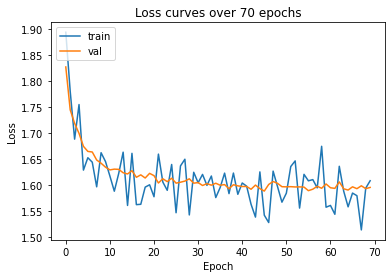

In [14]:
train_history = model.train_metrics
train_loss = train_history['train_loss']
val_loss = train_history['val_loss']
loss_curve(train_loss,val_loss,title="Loss curves over 70 epochs")

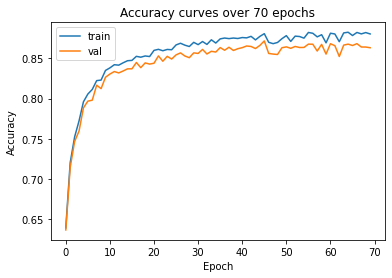

In [15]:
train_accuracy = train_history['train_accuracy']
val_accuracy = train_history['val_accuracy']
accuracy_curve(train_accuracy,val_accuracy,title="Accuracy curves over 70 epochs")

### Results - Model

In [16]:
test_data = test.data # 10K test images
test_data = test_data[:,None,...]
test_data = test_data.type(torch.FloatTensor).to(model.device)
test_data = (test_data - test_data.min())/(test_data.max() - test_data.min())

In [17]:
prediction = model(test_data)[0].max(1)[1]
ground_truth = test_loader.dataset.targets

In [18]:
prediction_cpu = prediction.cpu().numpy()
ground_truth_cpu = ground_truth.cpu().numpy()

<AxesSubplot:title={'center':'Confusion Matrix - Fashion MNIST'}, xlabel='True label', ylabel='Predicted label'>

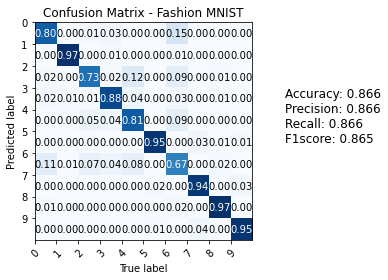

In [19]:
confusion_matrix(prediction_cpu,ground_truth_cpu,range(10),normalize=True,title = "Confusion Matrix - Fashion MNIST")

In [20]:
model.metrics_report(prediction_cpu,ground_truth_cpu)

,0,1,2,3,4,5,6,7,8,9
accuracy,0.798486,0.971029,0.729983,0.876907,0.808952,0.946131,0.671217,0.943262,0.968335,0.949153
f1-score,0.820613,0.971514,0.788408,0.869390,0.773486,0.955962,0.627994,0.937091,0.958060,0.950574
precision,0.844000,0.972000,0.857000,0.862000,0.741000,0.966000,0.590000,0.931000,0.948000,0.952000
recall,0.798486,0.971029,0.729983,0.876907,0.808952,0.946131,0.671217,0.943262,0.968335,0.949153
support,1057.000000,1001.000000,1174.000000,983.000000,916.000000,1021.000000,879.000000,987.000000,979.000000,1003.000000


In [21]:
model.classification_metrics(prediction.cpu().numpy(),ground_truth.cpu().numpy())

{'accuracy': 0.8663,
 'f1score': 0.8653092357996869,
 'precision': 0.8663000000000001,
 'recall': 0.8663456134222937,
 'support': None}

### Results - Noise activation

In [23]:
fmnist_noise_data = gabor.noise_frequency(model,fmnist_noise,batch_size=10000,n_classes=10)

  1%|          | 1/100 [00:06<11:16,  6.83s/it]
0 : 12435
1 : 2698
2 : 414645
3 : 548
4 : 75714
5 : 831
6 : 175041
7 : 314
8 : 317532
9 : 242


In [26]:
mean_noise = [(fmnist_noise_data[i].mean(axis=0)) for i in range(10)]
mean_noise = torch.stack(mean_noise).to('cpu')

In [34]:
#np.save('cache/fmnist_noise_average.npy',np.array(mean_noise.cpu()))

In [28]:
fmnist_noise_mean = np.load('cache/noise_avg_fashion.npy')

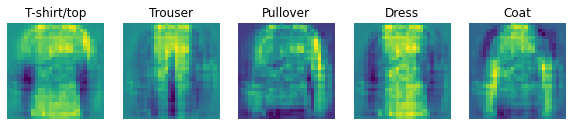

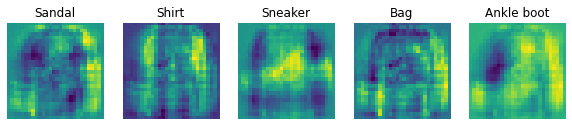

In [29]:
list_of_images = [fmnist_noise_mean[i] for i in range(10)]
list_of_titles = train.classes
grid_display(list_of_images,list_of_titles,5)

We now apply the generated noise patterns to an image to see how the prediction probability varies

torch.Size([1, 1, 28, 28])
class: 0, misclassification_rate: 1.0
class: 1, misclassification_rate: 0.0
class: 2, misclassification_rate: 0.0
class: 3, misclassification_rate: 1.0
class: 4, misclassification_rate: 0.0
class: 5, misclassification_rate: 1.0
class: 6, misclassification_rate: 1.0
class: 7, misclassification_rate: 1.0
class: 8, misclassification_rate: 1.0
class: 9, misclassification_rate: 1.0


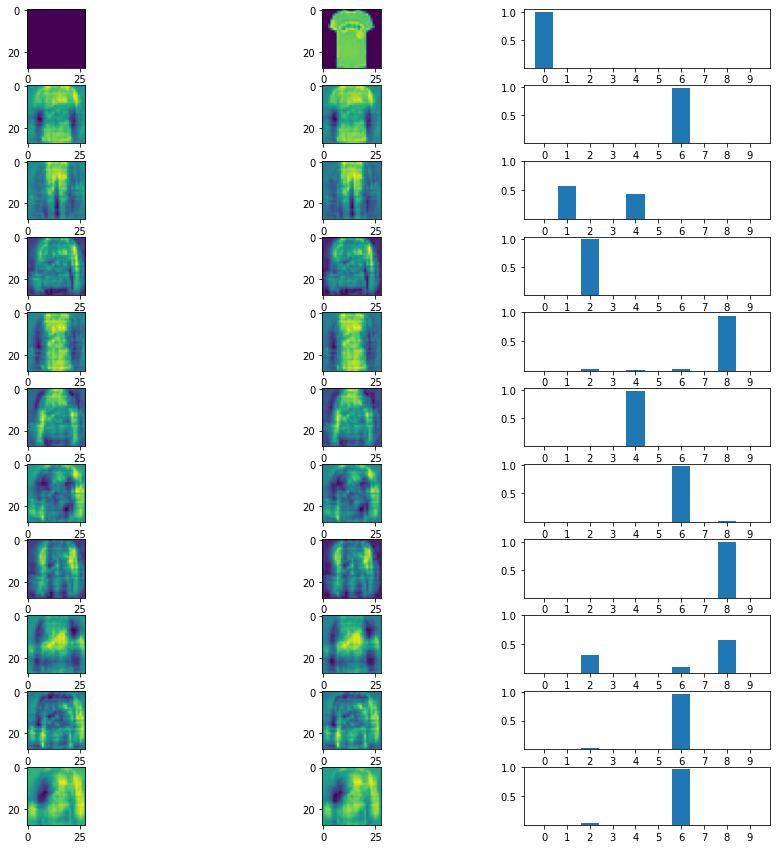

In [36]:
denoise = Denoise(model)
prediction_array,list_of_hist_im = denoise.noise_injection(torch.tensor(fmnist_noise_mean), weights=0.9, test_data=test.data, image_idx=19)
grid_histogram(data = prediction_array, rows=11, columns=3, list_of_images=list_of_hist_im)

In [37]:
prediction_transformed_cpu = model.prediction_transform(fmnist_noise_mean,test_data.cpu()).numpy()

<AxesSubplot:title={'center':'Confusion Matrix - Gabor Noisy FashionMNIST'}, xlabel='True label', ylabel='Predicted label'>

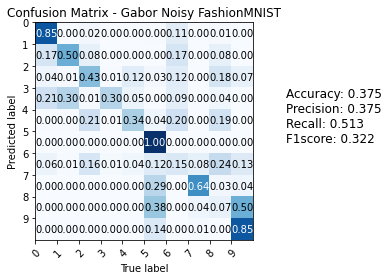

In [38]:
confusion_matrix(prediction_transformed_cpu,ground_truth_cpu,range(10),normalize=True,title = "Confusion Matrix - Gabor Noisy FashionMNIST")

We notice a sharp decrease in class-wise accuracy as we start seeing more variance throughout the confusion matrix. 

We perform the same analysis as above, however this time we will use random noise instead of gabor noise

In [39]:
prediction_frequency,rand_mean_noise = denoise.make_mean_activation_layer(size=1000000,batch_size=10000,n_classes=10,input_size=28)
rand_mean_noise = (rand_mean_noise -rand_mean_noise.min()) / (rand_mean_noise.max() -rand_mean_noise.min())

In [40]:
prediction_frequency

{0: tensor(339, device='cuda:0'),
 1: tensor(220, device='cuda:0'),
 2: tensor(72154, device='cuda:0'),
 3: tensor(391, device='cuda:0'),
 4: tensor(3431, device='cuda:0'),
 5: tensor(390, device='cuda:0'),
 6: tensor(667145, device='cuda:0'),
 7: tensor(33, device='cuda:0'),
 8: tensor(255743, device='cuda:0'),
 9: tensor(154, device='cuda:0')}

In [41]:
rand_mean_noise = rand_mean_noise.to('cuda')
pred_values = model(rand_mean_noise[:,None,...])[0].data.max(1)[1]

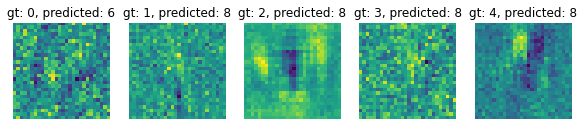

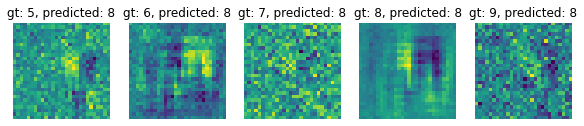

In [42]:
pred_gt_tuple = zip((range(10)),pred_values)
list_of_names = ["gt: {}, predicted: {}".format(i[0],i[1]) for i in pred_gt_tuple]
list_of_images = [i.cpu() for i in rand_mean_noise]
grid_display(list_of_images,list_of_names,5)

torch.Size([1, 1, 28, 28])
class: 0, misclassification_rate: 1.0
class: 1, misclassification_rate: 1.0
class: 2, misclassification_rate: 0.0
class: 3, misclassification_rate: 1.0
class: 4, misclassification_rate: 1.0
class: 5, misclassification_rate: 1.0
class: 6, misclassification_rate: 1.0
class: 7, misclassification_rate: 1.0
class: 8, misclassification_rate: 1.0
class: 9, misclassification_rate: 1.0


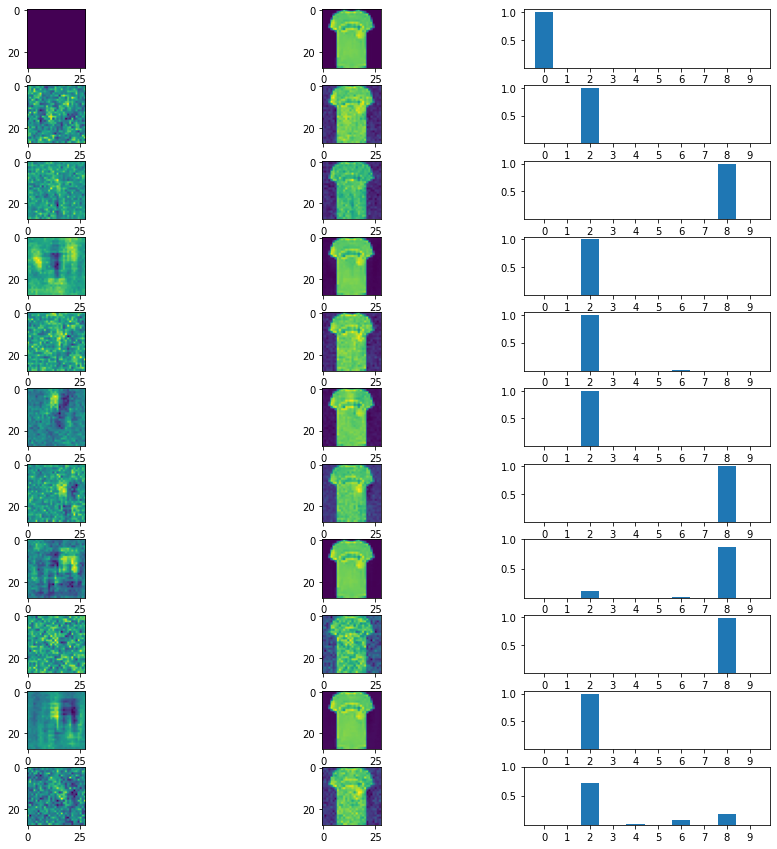

In [45]:
prediction_array_rand,list_of_hist_rand = denoise.noise_injection(torch.tensor(rand_mean_noise.cpu()), weights=0.5, test_data=test.data, image_idx=19)
grid_histogram(data = prediction_array_rand, rows=11, columns=3, list_of_images=list_of_hist_rand)

The only row with the correct prediction would be the first row, where no noise is applied.

### Spike Triggered Averaging

By defining the component sizes that make up a convolutional block, we can mathematically calculate the size of the input after being subsampled.
We define the convnet array to represent a layer's properties in the order [kernel size, stride, padding, number_channel]

In [46]:
STA = SpikeTriggeredAveraging(model,28)
convnet =   [[5,1,0,64], [2,2,0,0], [5,1,0,32], [2,2,0,0], [3,1,0,16], [2,2,0,0]]
layer_names = ['conv1','pool1','conv2','pool2','conv3','pool3']

In [47]:
STA.generate_rf_info(layer_names=layer_names,layer_list=convnet)

[2.5, 1, 5, 24, 64]
[3.0, 2, 6, 12, 0]
[7.0, 2, 14, 8, 32]
[8.0, 4, 16, 4, 0]
[12.0, 4, 24, 2, 16]


{'conv1': [2.5, 1, 5, 24, 64],
 'pool1': [3.0, 2, 6, 12, 0],
 'conv2': [7.0, 2, 14, 8, 32],
 'pool2': [8.0, 4, 16, 4, 0],
 'conv3': [12.0, 4, 24, 2, 16],
 'pool3': [14.0, 8, 28, 1, 0]}

We pass the training data through the CNN again but this time we record the responses of the convolutional layers after activation.



In [48]:
convolutional_layers = STA.get_features_from_cnn(train_data=train.data,conv_layers=3, batch_size=10000,pos_x=1,pos_y=1)

100%|██████████| 6/6 [00:00<00:00, 15.59it/s]


In [49]:
img_num = len(train.data)
train_data = train.data

# Record layer activation
conv_activation_1 = convolutional_layers['conv1_activation']
conv_activation_2 = convolutional_layers['conv2_activation']
conv_activation_3 = convolutional_layers['conv3_activation']

conv1_rf = torch.zeros(conv_activation_1.shape[1], 5, 5)
conv2_rf = torch.zeros(conv_activation_2.shape[1], 14, 14)
conv3_rf = torch.zeros(conv_activation_3.shape[1], 24, 24)

# Pad the image if needed to capture the layer activation
with tqdm(total=img_num, file=sys.stdout) as pbar:
    for i in range(img_num):
        image = train_data[i].type_as(torch.FloatTensor())
        conv1_rf += STA.padded_rf(layer_name = 'conv1',image = image, i=5,j=5)[None, ...].repeat(conv_activation_1.shape[1], 1, 1) * conv_activation_1[i][..., None, None]
        conv2_rf += STA.padded_rf(layer_name = 'conv2',image = image, i=5,j=5)[None, ...].repeat(conv_activation_2.shape[1], 1, 1) * conv_activation_2[i][..., None, None]
        conv3_rf += STA.padded_rf(layer_name = 'conv3',image = image, i=1,j=1)[None, ...].repeat(conv_activation_3.shape[1], 1, 1) * conv_activation_3[i][..., None, None]

        pbar.update(1)

100%|██████████| 60000/60000 [00:10<00:00, 5502.70it/s]


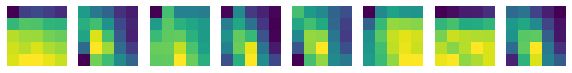

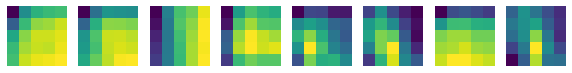

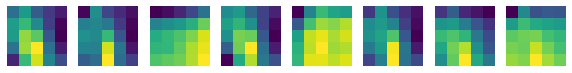

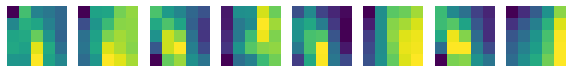

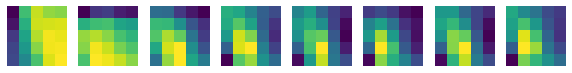

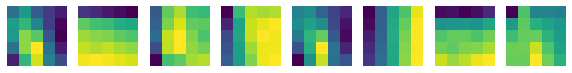

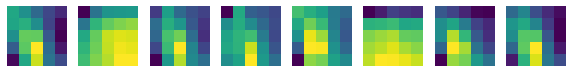

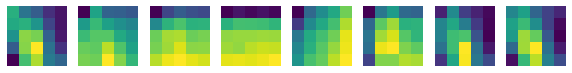

In [47]:
list_images_conv1 = [conv1_rf[i].numpy() for i in range(conv1_rf.shape[0])]
list_names_conv1 = [""] * conv1_rf.shape[0]
grid_display(list_images_conv1,list_names_conv1,8)

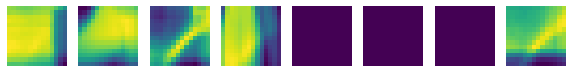

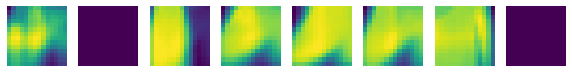

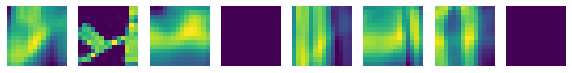

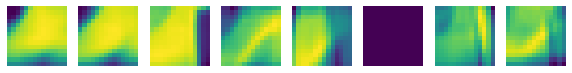

In [50]:
list_images_conv2 = [conv2_rf[i].numpy() for i in range(conv2_rf.shape[0])]
list_names_conv2 = [""] * conv2_rf.shape[0]
grid_display(list_images_conv2,list_names_conv2,8)

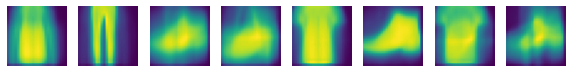

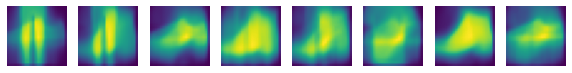

In [51]:
list_images_conv3 = [conv3_rf[i].numpy() for i in range(conv3_rf.shape[0])]
list_names_conv3 = [""] * conv3_rf.shape[0]
grid_display(list_images_conv3,list_names_conv3,8)

### Denoising

In [52]:
test_data = test.data # 10K test images
test_data =test_data[:,None,...]
test_data= test_data.type(torch.FloatTensor)
test_data= (test_data - test_data.min())/(test_data.max() - test_data.min())

In [54]:
weight_injection = 0.5
noise_pattern = rand_mean_noise[0].cpu()
injected_test = weight_injection*noise_pattern + (1-weight_injection)*(test_data.cpu().numpy())
injected_test = torch.tensor(injected_test).cuda()

In [55]:
with torch.no_grad():
    injected_prediction = model(injected_test)[0].max(1)[1]

<AxesSubplot:title={'center':'Confusion Matrix - 3-Gabor Noisy FashionMNIST'}, xlabel='True label', ylabel='Predicted label'>

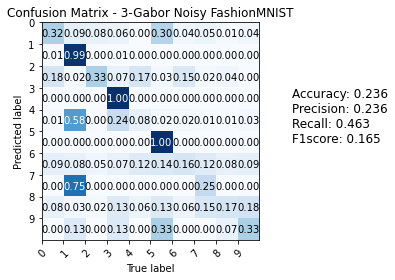

In [56]:
injected_prediction = injected_prediction.cpu().numpy()
ground_truth_test = test.targets.numpy()
confusion_matrix(injected_prediction,ground_truth_test,range(10),normalize=True,
                            title = "Confusion Matrix - 3-Gabor Noisy FashionMNIST")

We predict the results and notice that model accuracy dropped by around 50%. We notice that the row representing the 3rd class has predictions throughout all classes instead of being concentrated around the 3rd class diagonal.

List of denoising methods
- PCA
- Total Variation
- Bilateral
- Wavelet denoising
- Gaussian Blur
- NL Means
- BM 3D

In [77]:
def PCA_transform(image,percentage):
    pca = PCA(n_components=percentage)
    pca_fit = pca.fit(image)
    pca_transformed = pca_fit.transform(image)
    projection = pca_fit.inverse_transform(pca_transformed)
    return projection

In [78]:
pca_lambda = (lambda x: PCA_transform(x,0.99))
tv_lambda = (lambda x: denoise_tv_chambolle(x,weight=0.15,eps=0.0001,n_iter_max=200))
bilateral_lambda = (lambda x: denoise_bilateral(x,channel_axis=None,sigma_spatial=0.05))
wavelet_visushrink_lambda = (lambda x: denoise_wavelet(x, channel_axis=None, convert2ycbcr=False,
                           method='VisuShrink', mode='hard',sigma=1e-2,
                           rescale_sigma=True))
wavelet_bayes_lambda = (lambda x: denoise_wavelet(x, channel_axis=None, convert2ycbcr=False,
                           method='BayesShrink', mode='soft',
                           rescale_sigma=True))
gauss_lambda =(lambda x: gaussian(x,sigma=0.05,mode='constant',cval=0.0))
nl_means_lambda = (lambda x: denoise_nl_means(x, h=1.15*estimate_sigma(x,multichannel=False),
                                              fast_mode = True, patch_size = 3,
                                              patch_distance = 1, multichannel = False))
bm3d_lambda = (lambda x: bm3d.bm3d(x, sigma_psd=0.01, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING))

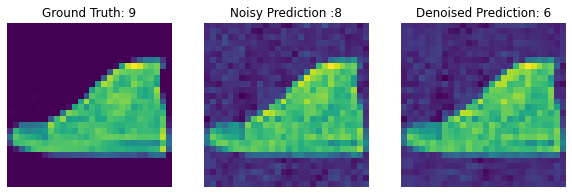

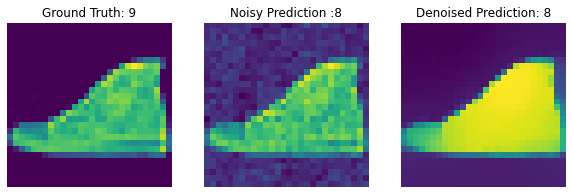

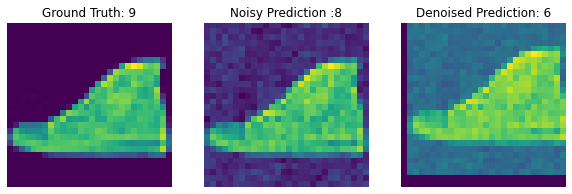

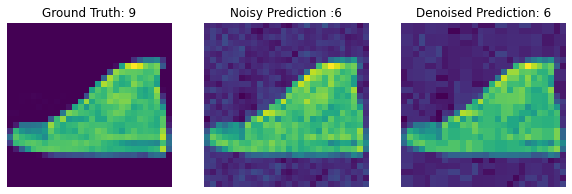

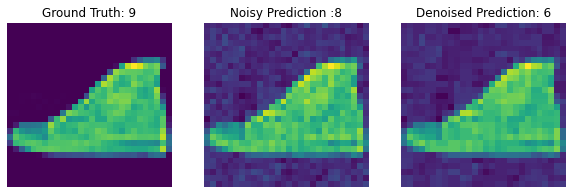

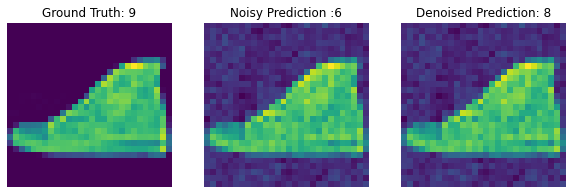

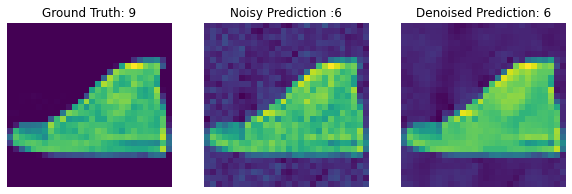

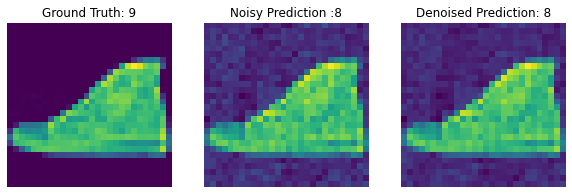

In [92]:
denoisers = [pca_lambda,tv_lambda,bilateral_lambda,wavelet_visushrink_lambda,wavelet_bayes_lambda,gauss_lambda,nl_means_lambda,bm3d_lambda]
for denoiser_ld in denoisers:
    l_img_pca,l_n_pca = denoise.denoising_image_prediction(rand_mean_noise[0].cpu(), test_data[1423],
                                                   test.targets[1423] ,denoiser_ld, weight_injection=0.5)
    grid_display(l_img_pca,l_n_pca,no_of_columns=3)
    

### Image segmentation


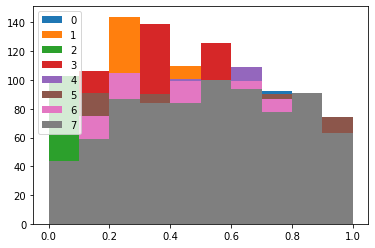

In [84]:
for denoiser in denoisers:
    test_image_mk = test_data[1423]
    weight_injection = 0.5
    noise_pattern = rand_mean_noise[0].cpu().numpy()
    injected_noise_k = weight_injection*noise_pattern + (1-weight_injection)*(test_image_mk.cpu().numpy())
    
    denoised_img_nl = denoiser(injected_noise_k.reshape(28,28))
    equalizer_img = exposure.equalize_adapthist(denoised_img_nl)
    plt.hist(equalizer_img.flat,bins=10,range=(0,1))
    handles = list(range(8))
    plt.legend(handles)

(array([ 19.,  80.,  71., 174., 108.,  46.,  52.,  79.,  97.,  58.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

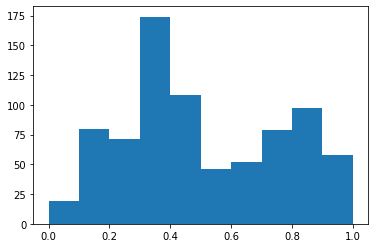

In [101]:
test_image_mk = test_data[1423]
weight_injection = 0.9
noise_pattern = rand_mean_noise[0].cpu().numpy()
injected_noise_k = weight_injection*noise_pattern + (1-weight_injection)*(test_image_mk.cpu().numpy())

denoised_img_nl = tv_lambda(injected_noise_k.reshape(28,28))
equalizer_img = exposure.equalize_adapthist(denoised_img_nl)
plt.hist(equalizer_img.flat,bins=10,range=(0,1))

In [117]:
train_data_mask = denoise.denoise_mask_transform(data = test.data,
                                         pixel = 28,
                                         noise_pattern = torch.tensor(rand_mean_noise[0].cpu()),
                                         noise_weight = 0.5,
                                         denoiser_lambda = tv_lambda,
                                         percentile_threshold = np.percentile(equalizer_img.flat,60))

In [118]:
with torch.no_grad():
    markers_dataset = torch.tensor(train_data_mask[:,None,...]).type(torch.FloatTensor).cuda()
    marked_pred = model(markers_dataset)[0].max(1)[1]
marked_pred

tensor([8, 8, 8,  ..., 6, 6, 6], device='cuda:0')

<AxesSubplot:title={'center':'Confusion Matrix - Marker FashionMNIST'}, xlabel='True label', ylabel='Predicted label'>

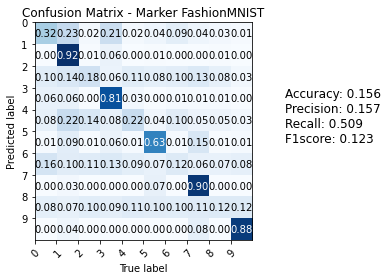

In [119]:
marked_pred = marked_pred.cpu().numpy()
ground_truth_test = test.targets.numpy()
confusion_matrix(marked_pred,ground_truth_test,range(10),normalize=True,
                            title = "Confusion Matrix - Marker FashionMNIST")

(array([ 87.,  95., 144.,  92., 110.,  43.,  64.,  64.,  50.,  35.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

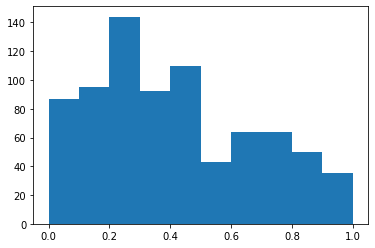

In [110]:
test_image_mk = test_data[1423]
weight_injection = 0.5
noise_pattern = rand_mean_noise[0].cpu().numpy()
injected_noise_k = weight_injection*noise_pattern + (1-weight_injection)*(test_image_mk.cpu().numpy())

denoised_img_nl = tv_lambda(injected_noise_k.reshape(28,28))
equalizer_img = exposure.equalize_adapthist(denoised_img_nl)
plt.hist(equalizer_img.flat,bins=10,range=(0,1))

In [111]:
markers = np.zeros((28,28))
threshold_q1 = np.percentile(equalizer_img,60)
#threshold_q3 = np.percentile(equalizer_img,50)
#print(threshold_q1)
markers[(equalizer_img < threshold_q1) ] = 0
#markers[(equalizer_img > threshold_q1) & (equalizer_img < threshold_q3)]  = 0
markers[(equalizer_img > threshold_q1)] = 1


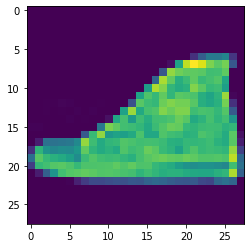

In [112]:
plt.imshow(test_data[1423].squeeze(0).cpu())

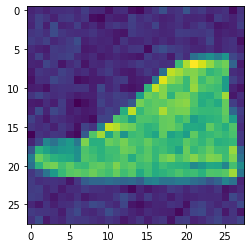

In [113]:
plt.imshow(injected_noise_k.reshape(28,28))

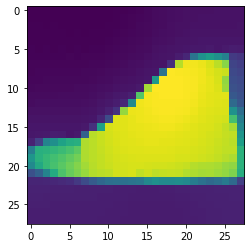

In [114]:
plt.imshow(denoised_img_nl)

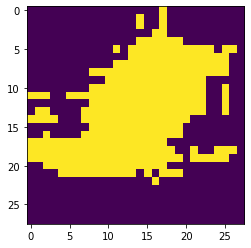

In [115]:
plt.imshow(markers)

In [248]:
markers.shape

(28, 28)

In [282]:
with torch.no_grad():
    marker = torch.tensor(markers[None,None,...]).type(torch.FloatTensor).cuda()
    marked_pred = model(marker)[0].max(1)[1]
marked_pred

tensor([6], device='cuda:0')

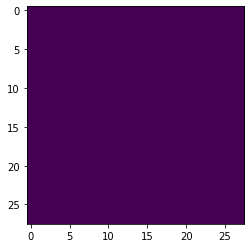

In [191]:
plt.imshow(markers)

0.0


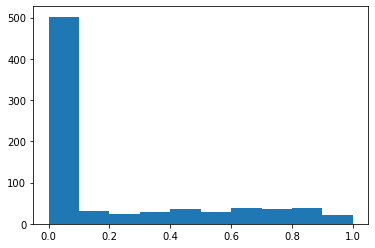

In [170]:

marker = denoise_mask_transform(data = test.data[5][None,...],
                                         pixel = 28,
                                         noise_pattern = mean_noise_basic[3],
                                         noise_weight = 0.9,
                                         denoiser_lambda = bm3d_lambda,
                                         percentile_threshold = np.percentile(equalizer_img.flat,75))

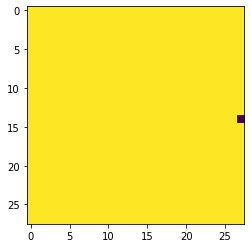

In [154]:
plt.imshow(marker.squeeze(0))